In [1]:
!pip install -q langgraph langchain langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.1 MB/s eta 0:00:00


In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Literal,Annotated
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
from google.colab import userdata
GROQ_API_KEY=userdata.get('GROQ_API_KEY')

In [4]:
llm=ChatGroq(
    model='openai/gpt-oss-20b',
    api_key=GROQ_API_KEY
)

In [5]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [6]:
def generate_joke(state:JokeState):

    prompt =f"generate a joke on the topic {state['topic']}"
    response=llm.invoke(prompt).content
    return {'joke':response}

In [11]:
def generate_explanation(state:JokeState):
    prompt=f"write a explanation about the joke:{state['joke']}"
    response=llm.invoke(prompt).content
    return {'explanation':response}

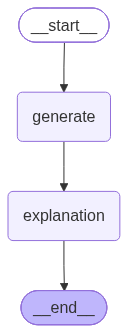

In [12]:
graph=StateGraph(JokeState)

graph.add_node('generate',generate_joke)
graph.add_node('explanation',generate_explanation)

graph.add_edge(START,'generate')
graph.add_edge('generate','explanation')
graph.add_edge('explanation',END)

checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [16]:
config1={"configurable":{"thread_id":"1"}}
workflow.invoke({'topic':'AI'},config=config1)

{'topic': 'AI',
 'joke': 'Why did the AI start a stand‑up comedy club?\n\nBecause it heard humans love *deep* learning—so it decided to *deeply* understand the punchlines!',
 'explanation': '**Explanation of the joke**\n\n> *Why did the AI start a stand‑up comedy club?  \n> Because it heard humans love *deep* learning—so it decided to *deeply* understand the punchlines!*\n\nThe humor comes from a clever play on words that blends two very different contexts: **machine‑learning terminology** and **comedy jargon**. Let’s break it down:\n\n| Element | What it normally means | How it’s used in the joke |\n|---------|------------------------|---------------------------|\n| **Deep learning** | A subset of artificial‑intelligence research that uses neural networks with many layers (“deep” layers) to learn patterns from data. | The joke says “humans love *deep* learning” as if people are fans of the AI technique, which is a common meme in tech circles. |\n| **Deeply understand** | To grasp some

In [17]:
config2={"configurable":{"thread_id":"2"}}
workflow.invoke({'topic':'I love u'},config=config2)

{'topic': 'I love u',
 'joke': 'Why did the emoji break up with the text “I love u”?\n\nBecause every time it tried to say “I love u,” it kept getting stuck in *“I love U”* mode and never got to the heart! 💔😂',
 'explanation': '### What’s the joke doing, step by step?\n\n| # | Element | Why it’s funny | How it ties into the punch‑line |\n|---|---------|----------------|---------------------------------|\n| 1 | **“I love u”** | It’s the classic texting shorthand for “I love you.” | The joke starts with a familiar phrase that almost everyone has typed. |\n| 2 | **Emoji vs. Text** | Emojis are visual, text is literal. The two “talk” to each other in a way that feels like a relationship. | The emoji “breaks up” with the text, anthropomorphizing both so we can imagine a romance. |\n| 3 | **“I love U” mode** | “U” can mean the letter *U* (uppercase) or the word *you*. The joke plays on the double meaning. | The emoji is stuck in a state where it’s only showing the letter *U*—not the word *yo

In [18]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'AI', 'joke': 'Why did the AI start a stand‑up comedy club?\n\nBecause it heard humans love *deep* learning—so it decided to *deeply* understand the punchlines!', 'explanation': '**Explanation of the joke**\n\n> *Why did the AI start a stand‑up comedy club?  \n> Because it heard humans love *deep* learning—so it decided to *deeply* understand the punchlines!*\n\nThe humor comes from a clever play on words that blends two very different contexts: **machine‑learning terminology** and **comedy jargon**. Let’s break it down:\n\n| Element | What it normally means | How it’s used in the joke |\n|---------|------------------------|---------------------------|\n| **Deep learning** | A subset of artificial‑intelligence research that uses neural networks with many layers (“deep” layers) to learn patterns from data. | The joke says “humans love *deep* learning” as if people are fans of the AI technique, which is a common meme in tech circles. |\n| **Deeply understan

In [19]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'I love u', 'joke': 'Why did the emoji break up with the text “I love u”?\n\nBecause every time it tried to say “I love u,” it kept getting stuck in *“I love U”* mode and never got to the heart! 💔😂', 'explanation': '### What’s the joke doing, step by step?\n\n| # | Element | Why it’s funny | How it ties into the punch‑line |\n|---|---------|----------------|---------------------------------|\n| 1 | **“I love u”** | It’s the classic texting shorthand for “I love you.” | The joke starts with a familiar phrase that almost everyone has typed. |\n| 2 | **Emoji vs. Text** | Emojis are visual, text is literal. The two “talk” to each other in a way that feels like a relationship. | The emoji “breaks up” with the text, anthropomorphizing both so we can imagine a romance. |\n| 3 | **“I love U” mode** | “U” can mean the letter *U* (uppercase) or the word *you*. The joke plays on the double meaning. | The emoji is stuck in a state where it’s only showing the letter *

In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'AI', 'joke': 'Why did the AI start a stand‑up comedy club?\n\nBecause it heard humans love *deep* learning—so it decided to *deeply* understand the punchlines!', 'explanation': '**Explanation of the joke**\n\n> *Why did the AI start a stand‑up comedy club?  \n> Because it heard humans love *deep* learning—so it decided to *deeply* understand the punchlines!*\n\nThe humor comes from a clever play on words that blends two very different contexts: **machine‑learning terminology** and **comedy jargon**. Let’s break it down:\n\n| Element | What it normally means | How it’s used in the joke |\n|---------|------------------------|---------------------------|\n| **Deep learning** | A subset of artificial‑intelligence research that uses neural networks with many layers (“deep” layers) to learn patterns from data. | The joke says “humans love *deep* learning” as if people are fans of the AI technique, which is a common meme in tech circles. |\n| **Deeply understa

In [22]:
for a in (list(workflow.get_state_history(config1))):
    print(a)

StateSnapshot(values={'topic': 'AI', 'joke': 'Why did the AI start a stand‑up comedy club?\n\nBecause it heard humans love *deep* learning—so it decided to *deeply* understand the punchlines!', 'explanation': '**Explanation of the joke**\n\n> *Why did the AI start a stand‑up comedy club?  \n> Because it heard humans love *deep* learning—so it decided to *deeply* understand the punchlines!*\n\nThe humor comes from a clever play on words that blends two very different contexts: **machine‑learning terminology** and **comedy jargon**. Let’s break it down:\n\n| Element | What it normally means | How it’s used in the joke |\n|---------|------------------------|---------------------------|\n| **Deep learning** | A subset of artificial‑intelligence research that uses neural networks with many layers (“deep” layers) to learn patterns from data. | The joke says “humans love *deep* learning” as if people are fans of the AI technique, which is a common meme in tech circles. |\n| **Deeply understan

In [23]:
for a in (list(workflow.get_state_history(config2))):
    print(a)

StateSnapshot(values={'topic': 'I love u', 'joke': 'Why did the emoji break up with the text “I love u”?\n\nBecause every time it tried to say “I love u,” it kept getting stuck in *“I love U”* mode and never got to the heart! 💔😂', 'explanation': '### What’s the joke doing, step by step?\n\n| # | Element | Why it’s funny | How it ties into the punch‑line |\n|---|---------|----------------|---------------------------------|\n| 1 | **“I love u”** | It’s the classic texting shorthand for “I love you.” | The joke starts with a familiar phrase that almost everyone has typed. |\n| 2 | **Emoji vs. Text** | Emojis are visual, text is literal. The two “talk” to each other in a way that feels like a relationship. | The emoji “breaks up” with the text, anthropomorphizing both so we can imagine a romance. |\n| 3 | **“I love U” mode** | “U” can mean the letter *U* (uppercase) or the word *you*. The joke plays on the double meaning. | The emoji is stuck in a state where it’s only showing the letter *

In [24]:
workflow.get_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b7192-5540-67e8-bfff-ccfb00733038'}})

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b7192-5540-67e8-bfff-ccfb00733038'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-09-23T06:36:45.352527+00:00', parent_config=None, tasks=(PregelTask(id='b5ce58aa-3b71-78fb-1d50-275aa703124a', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'I love u'}),), interrupts=())

In [25]:
workflow.get_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b7192-554c-6c69-8000-1cffc36ef120'}})

StateSnapshot(values={'topic': 'I love u'}, next=('generate',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b7192-554c-6c69-8000-1cffc36ef120'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-23T06:36:45.357546+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b7192-5540-67e8-bfff-ccfb00733038'}}, tasks=(PregelTask(id='df1e45a6-4aa0-c22e-0d8b-c6b8d804c980', name='generate', path=('__pregel_pull', 'generate'), error=None, interrupts=(), state=None, result={'joke': 'Why did the romantic robot keep texting “I love u” to the Wi‑Fi router?\n\nBecause it heard that a good connection always ends with a “byte”!'}),), interrupts=())

In [26]:
workflow.update_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b7192-5540-67e8-bfff-ccfb00733038'}},{'topic':'I hate u'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b71a3-ff56-6297-8000-fc0d54398ac8'}}

In [27]:
for a in (list(workflow.get_state_history(config2))):
    print(a)

StateSnapshot(values={'topic': 'I hate u'}, next=('generate',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b71a3-ff56-6297-8000-fc0d54398ac8'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-09-23T06:44:39.527435+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b7192-5540-67e8-bfff-ccfb00733038'}}, tasks=(PregelTask(id='e042ebb5-c1d0-8c46-67c2-37b8d9c1b011', name='generate', path=('__pregel_pull', 'generate'), error=None, interrupts=(), state=None, result=None),), interrupts=())
StateSnapshot(values={'topic': 'I love u', 'joke': 'Why did the emoji break up with the text “I love u”?\n\nBecause every time it tried to say “I love u,” it kept getting stuck in *“I love U”* mode and never got to the heart! 💔😂', 'explanation': '### What’s the joke doing, step by step?\n\n| # | Element | Why it’s funny | How it ties into the punch‑line |\n|---|---------|----------------|----

In [28]:
workflow.invoke(None,{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b71a3-ff56-6297-8000-fc0d54398ac8'}})

{'topic': 'I hate u',
 'joke': 'Why did the keyboard break up with the user?\n\nBecause every time the user typed “I hate u,” the keyboard just replied, “I’m sorry, I can’t process that—please rephrase!”',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Anthropomorphism** | The keyboard is treated like a person who can “break up.” | We’re used to people ending relationships, not inanimate objects. That mismatch is the first punchline. |\n| **The “I hate u” text** | A classic breakup line, but spelled “u” (the letter “you”). | It’s a play on words: the user literally types the word “u” (the keyboard’s own symbol) while expressing hate. The keyboard is literally being insulted by its own letters. |\n| **The keyboard’s reply** | “I’m sorry, I can’t process that—please rephrase!” | That’s the exact wording you see on a computer when it can’t understand a command. It’s the machine’s poli

In [29]:
for a in (list(workflow.get_state_history(config2))):
    print(a)

StateSnapshot(values={'topic': 'I hate u', 'joke': 'Why did the keyboard break up with the user?\n\nBecause every time the user typed “I hate u,” the keyboard just replied, “I’m sorry, I can’t process that—please rephrase!”', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Anthropomorphism** | The keyboard is treated like a person who can “break up.” | We’re used to people ending relationships, not inanimate objects. That mismatch is the first punchline. |\n| **The “I hate u” text** | A classic breakup line, but spelled “u” (the letter “you”). | It’s a play on words: the user literally types the word “u” (the keyboard’s own symbol) while expressing hate. The keyboard is literally being insulted by its own letters. |\n| **The keyboard’s reply** | “I’m sorry, I can’t process that—please rephrase!” | That’s the exact wording you see on a computer when it can’t understand a command. It’s